# Main paper results

This notebook reproduces Table 1 and Figures 2–4 of the paper. Appendix results are in `02_additional_results.ipynb`.

All VOI results use the verified Step 3b timestamps, volume-trusted hourly prices, and an averaging window of $W=24$ hours.

In [1]:
%config InlineBackend.figure_format = 'png'

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t, ttest_1samp, pearsonr
from sklearn.metrics import brier_score_loss, roc_auc_score
from adjustText import adjust_text

ROOT          = Path('..').resolve()  # cruxbench root (run notebook from cruxbench/notebook/)
OUTPUTS_DIR   = ROOT / 'outputs'
HOURLY_CACHE  = ROOT / 'data/hourly_prices_trusted'
FORECAST_DIR  = ROOT / 'outputs_forecast'
ULTIMATES     = ROOT / 'data/ultimates.json'
SIM_PAIRS     = OUTPUTS_DIR / 'crossmodel_similarity_pairs.json'
FIG_DIR       = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

sys.path.insert(0, str(ROOT))
from src.metrics import (
    before_after_prices, kl_bernoulli, load_hourly,
    pivot_hour, significance_stars,
)


In [2]:
GENERATORS = [
    ('claude-opus-4-6',        'claude-opus-4-6'),
    ('gpt-5.4',                'gpt-5.4'),
    ('gpt-3.5-turbo-1106',     'gpt-3.5-turbo-1106'),
    ('gemini-3.1-pro-preview', 'gemini-3.1-pro-preview'),
    ('llama-3.3-70B',          'together/meta-llama/Llama-3.3-70B-Instruct-Turbo'),
    ('qwen3-235B',             'together/Qwen/Qwen3-235B-A22B-Instruct-2507-tput'),
    ('deepseek-v3.1',          'together/deepseek-ai/DeepSeek-V3.1'),
    ('llama-3.1-8B',           'vllm/meta-llama/Llama-3.1-8B-Instruct'),
]

# The paper uses a dated ECI snapshot so Figure 2 is reproducible. Set this
# to True to read the latest scores directly from Epoch instead.
USE_LATEST_ECI = False
ECI_URL = 'https://epoch.ai/data/eci_scores.csv'
ECI_SNAPSHOT_DATE = '2026-09-22'
ECI_SNAPSHOT_PATH = OUTPUTS_DIR.parent / 'data' / f'epoch_eci_scores_{ECI_SNAPSHOT_DATE}.csv'
ECI_MODEL_NAMES = {
    'claude-opus-4-6':        'Claude Opus 4.6',
    'gpt-5.4':                'GPT-5.4',
    'deepseek-v3.1':          'DeepSeek-V3.1',
    'qwen3-235B':             'Qwen3-235B-A22B-Instruct (Jul 2025)',
    'llama-3.3-70B':          'Llama 3.3 70B',
    'gpt-3.5-turbo-1106':     'GPT-3.5 Turbo (Nov 2023)',
    'llama-3.1-8B':           'Llama 3.1-8B',
    'gemini-3.1-pro-preview': 'Gemini 3.1 Pro',
}

eci_source = ECI_URL if USE_LATEST_ECI else ECI_SNAPSHOT_PATH
eci_data = pd.read_csv(eci_source).set_index('Model')
missing_eci = sorted(set(ECI_MODEL_NAMES.values()) - set(eci_data.index))
assert not missing_eci, f'Missing ECI rows: {missing_eci}'
EPOCH_SCORES = {
    model: float(eci_data.loc[epoch_name, 'eci'])
    for model, epoch_name in ECI_MODEL_NAMES.items()
}
print(f"ECI source: {'latest download' if USE_LATEST_ECI else 'paper snapshot ' + ECI_SNAPSHOT_DATE}")

PALETTE = {
    'claude-opus-4-6':        '#C44E52',
    'gpt-5.4':                '#55A868',
    'deepseek-v3.1':          '#4C72B0',
    'qwen3-235B':             '#8172B3',
    'llama-3.3-70B':          '#CCB974',
    'gpt-3.5-turbo-1106':     '#64B5CD',
    'llama-3.1-8B':           '#937860',
    'gemini-3.1-pro-preview': '#DA8BC3',
}

dfs_raw = {name: pd.read_json(OUTPUTS_DIR / sub / 'resolved.json')
           for name, sub in GENERATORS}
print(f'loaded {len(dfs_raw)} generators')

# One representative row per unique market id (rows are duplicated across generators).
market_registry = {}
for df in dfs_raw.values():
    for _, row in df.iterrows():
        mid = int(row['id'])
        if mid not in market_registry:
            market_registry[mid] = row
print(f'{len(market_registry)} unique markets')


FORECAST_SAFE = {
    'claude-opus-4-6': 'claude-opus-4-6',
    'gpt-5.4': 'gpt-5.4',
    'gpt-3.5-turbo-1106': 'gpt-3.5-turbo-1106',
    'gemini-3.1-pro-preview': 'gemini-3.1-pro-preview',
    'llama-3.3-70B': 'together_meta-llama_Llama-3.3-70B-Instruct-Turbo',
    'qwen3-235B': 'together_Qwen_Qwen3-235B-A22B-Instruct-2507-tput',
    'deepseek-v3.1': 'together_deepseek-ai_DeepSeek-V3.1',
    'llama-3.1-8B': 'vllm_meta-llama_Llama-3.1-8B-Instruct',
}

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


ECI source: paper snapshot 2026-09-22
loaded 8 generators


293 unique markets


In [3]:
missing = [mid for mid in market_registry
           if not (HOURLY_CACHE / f'{mid}.json').exists()]
if missing:
    raise FileNotFoundError(
        f'{len(missing)} trusted price histories are missing. '
        'Run: python data_collection/build_trusted_prices.py'
    )

hourly = {mid: load_hourly(mid, HOURLY_CACHE) for mid in market_registry}
hourly = {mid: s for mid, s in hourly.items() if s is not None and len(s) > 0}
print(f'loaded {len(hourly)} hourly series')


loaded 293 hourly series


In [4]:
def kl_at_w(resolved_markets, window_hours):
    rows = []
    for _, market in resolved_markets.iterrows():
        series = hourly.get(int(market['id']))
        if series is None:
            continue

        before, after = before_after_prices(series, window_hours)
        for window in market['active_windows']:
            start = pd.to_datetime(window['start'], utc=True).floor('1h')
            end = pd.to_datetime(window['end'], utc=True).floor('1h') + pd.Timedelta(hours=23)
            in_window = (before.index >= start) & (before.index <= end)
            p_before = before[in_window].values
            p_after = after[in_window].values
            valid = ~(pd.isna(p_before) | pd.isna(p_after))
            if valid.sum() == 0:
                continue

            candidate_kl = kl_bernoulli(p_after[valid], p_before[valid])
            cruxes = window.get('subquestions') or []
            crux = cruxes[0] if cruxes else {}
            realized_kl = 0.0

            resolution_datetime = crux.get('resolution_datetime')
            if resolution_datetime and crux.get('resolvable'):
                pivot = pivot_hour(pd.to_datetime(resolution_datetime, utc=True))
                price_before = before.get(pivot, np.nan)
                price_after = after.get(pivot, np.nan)
                if not (pd.isna(price_before) or pd.isna(price_after)):
                    realized_kl = float(kl_bernoulli(price_after, price_before))

            rows.append({
                'kl': realized_kl,
                'random_kl': float(candidate_kl.mean()),
                'oracle_kl': float(candidate_kl.max()),
            })
    return pd.DataFrame(rows)


def one_sided_p_value(realized, random):
    difference = np.asarray(realized) - np.asarray(random)
    return float(ttest_1samp(difference, 0, alternative='greater').pvalue)


In [5]:
W = 24
raw = {model: kl_at_w(frame, W) for model, frame in dfs_raw.items()}
assert all(len(frame) == 293 for frame in raw.values())
p_values = {
    model: one_sided_p_value(frame['kl'], frame['random_kl'])
    for model, frame in raw.items()
}
print(f'W={W}h  n_per_model={next(iter(raw.values())).shape[0]}')


W=24h  n_per_model=293


## Table 1: VOI performance by model

In [6]:
PAPER_NAMES = {
    'claude-opus-4-6': 'Claude-Opus-4.6',
    'gemini-3.1-pro-preview': 'Gemini-3.1-Pro-Preview',
    'gpt-5.4': 'GPT-5.4',
    'deepseek-v3.1': 'DeepSeek-V3.1',
    'qwen3-235B': 'Qwen3-235B-A22B',
    'llama-3.3-70B': 'Llama-3.3-70B',
    'llama-3.1-8B': 'Llama-3.1-8B-Instruct',
    'gpt-3.5-turbo-1106': 'GPT-3.5-Turbo',
}
KNOWLEDGE_CUTOFF = {
    'claude-opus-4-6': 'Aug 2025',
    'gemini-3.1-pro-preview': 'Jan 2025',
    'gpt-5.4': 'Aug 2025',
    'deepseek-v3.1': 'Aug 2025†',
    'qwen3-235B': 'Jul 2025†',
    'llama-3.3-70B': 'Dec 2023',
    'llama-3.1-8B': 'Dec 2023',
    'gpt-3.5-turbo-1106': 'Sep 2021',
}
VOI_COLUMN = 'VOI^KL (bits)'


def _mean_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    mean = float(values.mean())
    half_width = float(
        t.ppf((1 + confidence) / 2, len(values) - 1)
        * values.std(ddof=1) / np.sqrt(len(values))
    )
    return mean, mean - half_width, mean + half_width


def _resolved_count(df):
    return sum(
        bool(subq.get('resolvable'))
        for _, row in df.iterrows()
        for window in row['active_windows']
        for subq in (window.get('subquestions') or [])[:1]
    )


assert set(raw) == set(dfs_raw)
assert all(len(frame) == 293 for frame in raw.values())

reference = next(iter(raw.values()))
for frame in raw.values():
    assert np.allclose(frame['random_kl'], reference['random_kl'])
    assert np.allclose(frame['oracle_kl'], reference['oracle_kl'])

model_stats = {}
for model, frame in raw.items():
    mean, lo, hi = _mean_ci(frame['kl'])
    resolved = _resolved_count(dfs_raw[model])
    model_stats[model] = {
        'mean': mean,
        'lo': lo,
        'hi': hi,
        'resolved': resolved,
        'rate': resolved / len(frame),
        'p': p_values[model],
    }

rows = []
model_order = sorted(model_stats, key=lambda name: model_stats[name]['mean'], reverse=True)
for model in model_order:
    stat = model_stats[model]
    rows.append({
        'Model': PAPER_NAMES[model],
        VOI_COLUMN: f"{stat['mean']:.3f}{significance_stars(stat['p'])}",
        '95% CI': f"[{stat['lo']:.3f}, {stat['hi']:.3f}]",
        '# resolved (rate)': f"{stat['resolved']} ({stat['rate']:.1%})",
        'Knowledge cutoff': KNOWLEDGE_CUTOFF[model],
    })

for label, column in [('Random baseline', 'random_kl'), ('Oracle', 'oracle_kl')]:
    mean, lo, hi = _mean_ci(reference[column])
    rows.append({
        'Model': label,
        VOI_COLUMN: f'{mean:.3f}',
        '95% CI': f'[{lo:.3f}, {hi:.3f}]',
        '# resolved (rate)': '—',
        'Knowledge cutoff': '—',
    })

paper_table_1 = pd.DataFrame(rows)
best_idx = paper_table_1.iloc[:-2][VOI_COLUMN].str.extract(r'([0-9.]+)')[0].astype(float).idxmax()
resolved_idx = max(
    range(len(model_stats)),
    key=lambda i: int(paper_table_1.loc[i, '# resolved (rate)'].split()[0]),
)

voi_by_model = pd.DataFrame({
    'KL': {model: frame['kl'].mean() for model, frame in raw.items()},
    'random_KL': {model: frame['random_kl'].mean() for model, frame in raw.items()},
})

print(f'Performance on CruxBench (n={len(reference)}, W={W}h)')
display(
    paper_table_1.style.hide(axis='index')
    .set_properties(subset=pd.IndexSlice[[best_idx], [VOI_COLUMN]], **{'font-weight': 'bold'})
    .set_properties(subset=pd.IndexSlice[[resolved_idx], ['# resolved (rate)']], **{'font-weight': 'bold'})
)


Performance on CruxBench (n=293, W=24h)


Model,VOI^KL (bits),95% CI,# resolved (rate),Knowledge cutoff
Claude-Opus-4.6,0.016**,"[0.009, 0.023]",279 (95.2%),Aug 2025
Gemini-3.1-Pro-Preview,0.014*,"[0.007, 0.020]",274 (93.5%),Jan 2025
GPT-5.4,0.013*,"[0.007, 0.019]",268 (91.5%),Aug 2025
DeepSeek-V3.1,0.012,"[0.003, 0.020]",262 (89.4%),Aug 2025†
Qwen3-235B-A22B,0.012,"[0.005, 0.018]",271 (92.5%),Jul 2025†
Llama-3.3-70B,0.010,"[0.005, 0.016]",252 (86.0%),Dec 2023
Llama-3.1-8B-Instruct,0.010,"[0.005, 0.015]",271 (92.5%),Dec 2023
GPT-3.5-Turbo,0.009,"[0.005, 0.013]",275 (93.9%),Sep 2021
Random baseline,0.007,"[0.006, 0.009]",—,—
Oracle,0.129,"[0.100, 0.157]",—,—


## Shared forecasting and plotting setup

In [7]:
VOI_LABEL = r'$\widehat{\mathrm{VOI}}^{\mathrm{KL}}$'
KEY = ['ultimate_question', 'period_idx']


def _scatter_panel(ax, df_xy, x_col, y_col, *, flip_x=False,
                   x_metric_label, y_metric_label=None, baseline_x=None,
                   title_prefix=''):
    raw_x = df_xy[x_col].values
    x = -raw_x if flip_x else raw_x
    y = df_xy[y_col].values
    r, p = pearsonr(x, y)

    xlo, xhi = float(x.min()), float(x.max())
    if baseline_x is not None:
        xlo, xhi = min(xlo, baseline_x), max(xhi, baseline_x)

    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(xlo, xhi, 50)
    ax.plot(xs, slope * xs + intercept, color='#555', lw=1.4, alpha=0.55,
            zorder=1, label='OLS fit')
    if baseline_x is not None:
        ax.axvline(baseline_x, color='black', ls='--', lw=1.3, alpha=0.75,
                   label=f'no-crux baseline = {baseline_x:+.3f}')

    texts = []
    for model, row in df_xy.iterrows():
        xv = -row[x_col] if flip_x else row[x_col]
        color = PALETTE.get(model, '#333')
        ax.scatter(xv, row[y_col], s=200, alpha=0.95, edgecolors='black',
                   linewidths=1.0, color=color, zorder=3)
        texts.append(ax.text(xv, row[y_col], model, fontsize=11,
                             fontweight='bold', color=color))

    title_core = f'{y_metric_label} vs {x_metric_label}' if y_metric_label else x_metric_label
    ax.set_title(rf'{title_prefix}{title_core}    ($r$ = {r:+.2f}{significance_stars(p)})', fontsize=16)
    ax.set_xlabel(rf'{x_metric_label}  ($\uparrow$ better)')
    ax.grid(True, ls=':', alpha=0.5)
    pad = 0.10 * (xhi - xlo if xhi > xlo else max(abs(xhi), 1e-3))
    ax.set_xlim(xlo - pad, xhi + pad)
    adjust_text(
        texts, ax=ax, expand=(1.4, 1.6),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.7, alpha=0.7),
        only_move={'text': 'xy', 'static': 'xy'},
    )
    return r, p


ultimates = pd.read_json(ULTIMATES)
ultimates['y'] = ultimates['resolution'].map({'Yes': 1, 'No': 0})
ground_truth_rows = []
for _, row in ultimates.iterrows():
    if pd.isna(row['y']):
        continue
    for window in row['active_windows']:
        ground_truth_rows.append({
            'ultimate_question': row['question'],
            'period_idx': window['period_idx'],
            'y': int(row['y']),
        })
df_gt = pd.DataFrame(ground_truth_rows)


## Figure 2: VOI and model capability

In [8]:
self_performance = {}
for model, _ in GENERATORS:
    safe = FORECAST_SAFE[model]
    baseline = pd.read_json(FORECAST_DIR / safe / 'baseline_pu.json')[KEY + ['p_u']]
    baseline = baseline.rename(columns={'p_u': 'baseline'})
    merged = df_gt.merge(baseline, on=KEY, how='left').dropna(subset=['baseline'])
    y, probability = merged['y'].values, merged['baseline'].values
    self_performance[model] = {
        'brier P(U)': brier_score_loss(y, probability),
        'auc P(U)': roc_auc_score(y, probability),
    }

capability_df = voi_by_model[['KL', 'random_KL']].join(pd.DataFrame(self_performance).T).dropna()
capability_df.round(4)


,KL,random_KL,brier P(U),auc P(U)
claude-opus-4-6,0.0158,0.0073,0.2048,0.6914
gpt-5.4,0.0129,0.0073,0.2078,0.6803
gpt-3.5-turbo-1106,0.0088,0.0073,0.3967,0.4907
gemini-3.1-pro-preview,0.0136,0.0073,0.1950,0.7265
llama-3.3-70B,0.0105,0.0073,0.2365,0.6166
qwen3-235B,0.0115,0.0073,0.2596,0.5629
deepseek-v3.1,0.0117,0.0073,0.2224,0.6333
llama-3.1-8B,0.0100,0.0073,0.2631,0.5793


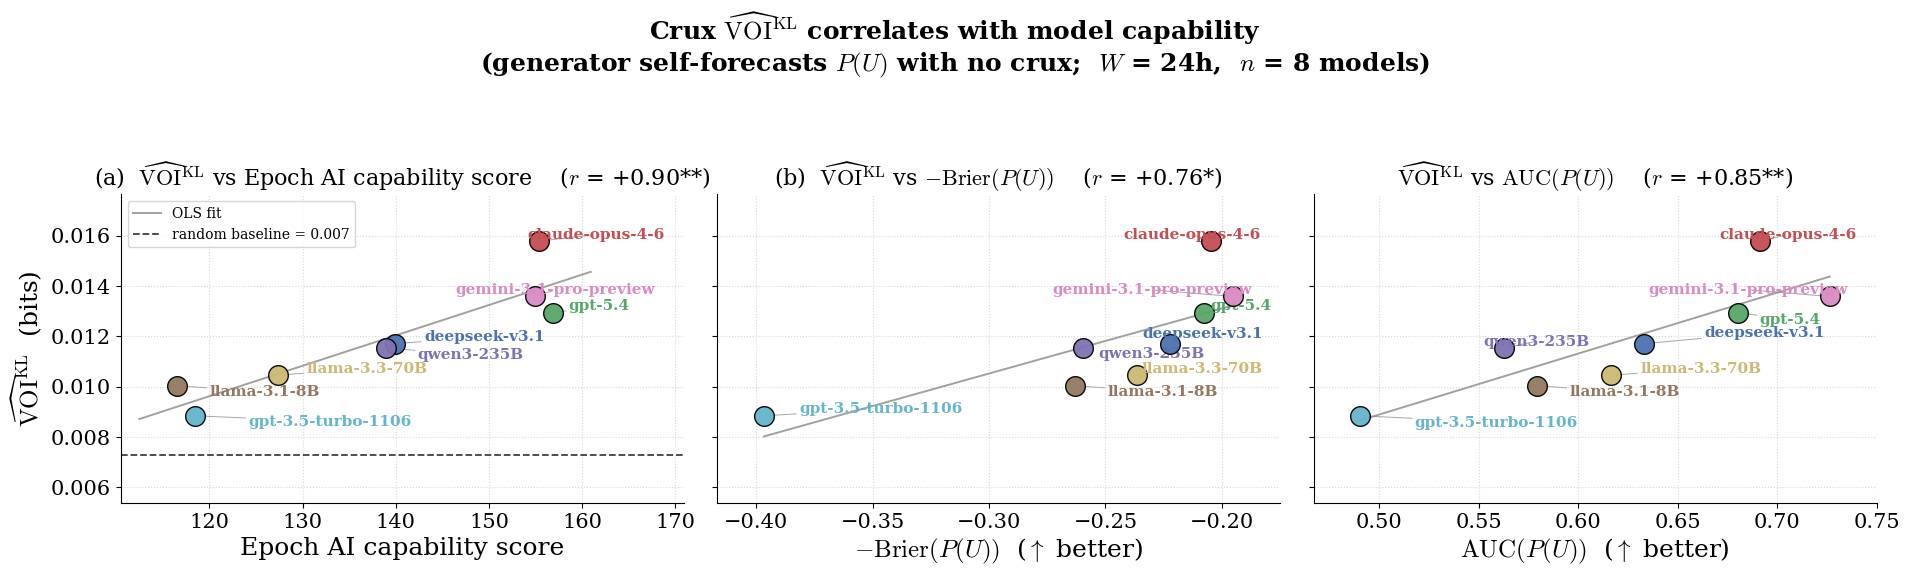

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(19.2, 5.6), sharey=True)
ax_a, ax_b1, ax_b2 = axes

# (a) VOI vs Epoch AI capability score
epoch_df = capability_df.loc[capability_df.index.isin(EPOCH_SCORES)].copy()
epoch_df['epoch'] = [EPOCH_SCORES[model] for model in epoch_df.index]
epoch_df = epoch_df.sort_values('epoch', ascending=False)
x, y = epoch_df['epoch'].values, epoch_df['KL'].values
random_baseline = float(epoch_df['random_KL'].mean())
r, p = pearsonr(x, y)
slope, intercept = np.polyfit(x, y, 1)
xs = np.linspace(x.min() - 4, x.max() + 4, 50)
ax_a.plot(xs, slope * xs + intercept, color='#555', lw=1.4, alpha=0.55,
          label='OLS fit')
ax_a.axhline(random_baseline, color='black', ls='--', lw=1.3, alpha=0.75,
             label=f'random baseline = {random_baseline:.3f}')
texts = []
for model, row in epoch_df.iterrows():
    color = PALETTE.get(model, '#333')
    ax_a.scatter(row['epoch'], row['KL'], s=200, alpha=0.95,
                 edgecolors='black', linewidths=1.0, color=color, zorder=3)
    texts.append(ax_a.text(row['epoch'], row['KL'], model, fontsize=11,
                           fontweight='bold', color=color))
ax_a.set_title(rf'(a)  {VOI_LABEL} vs Epoch AI capability score    '
               rf'($r$ = {r:+.2f}{significance_stars(p)})', fontsize=16)
ax_a.set_xlabel('Epoch AI capability score')
ax_a.set_ylabel(rf'{VOI_LABEL}  (bits)')
ax_a.set_xlim(x.min() - 6, x.max() + 14)
ax_a.grid(True, ls=':', alpha=0.5)
ax_a.legend(loc='upper left', frameon=True)
adjust_text(texts, ax=ax_a, expand=(1.4, 1.6),
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.7, alpha=0.7),
            only_move={'text': 'xy', 'static': 'xy'})

# (b) VOI vs each generator's own no-crux forecasting performance
_scatter_panel(ax_b1, capability_df, x_col='brier P(U)', y_col='KL', flip_x=True,
               x_metric_label=r'$-\mathrm{Brier}(P(U))$', y_metric_label=VOI_LABEL,
               title_prefix='(b)  ')
_scatter_panel(ax_b2, capability_df, x_col='auc P(U)', y_col='KL', flip_x=False,
               x_metric_label=r'$\mathrm{AUC}(P(U))$', y_metric_label=VOI_LABEL)

y_all = np.concatenate([y, capability_df['KL'].values, [random_baseline]])
y_pad = 0.22 * (y_all.max() - y_all.min())
ax_a.set_ylim(y_all.min() - y_pad, y_all.max() + y_pad)
for ax in axes:
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    ax.tick_params(axis='both', labelsize=15)

fig.suptitle(rf'Crux {VOI_LABEL} correlates with model capability'
             '\n'
             rf'(generator self-forecasts $P(U)$ with no crux;  $W$ = {W}h,  $n$ = {len(capability_df)} models)',
             fontsize=18, fontweight='bold', y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / 'voi_vs_capability.pdf', bbox_inches='tight')
plt.show()


## Figure 3: VOI and downstream forecasting utility

In [10]:
EXTERNAL_FORECASTERS = [
    'claude-haiku-4-5-20251001',
    'gemini-3-flash-preview',
    'gpt-5-mini',
]

wide = df_gt.copy()
for forecaster in EXTERNAL_FORECASTERS:
    baseline = pd.read_json(FORECAST_DIR / forecaster / 'baseline_pu.json')[KEY + ['p_u']]
    baseline = baseline.rename(columns={'p_u': f'baseline_{forecaster}'})
    wide = wide.merge(baseline, on=KEY, how='left')
    wide[f'baseline_{forecaster}'] = wide[f'baseline_{forecaster}'].fillna(0.5)

wide['cross_baseline'] = wide[
    [f'baseline_{forecaster}' for forecaster in EXTERNAL_FORECASTERS]
].mean(axis=1)

for model, _ in GENERATORS:
    safe = FORECAST_SAFE[model]
    arm_columns = []
    for forecaster in EXTERNAL_FORECASTERS:
        column = f'{model}_{forecaster}'
        path = FORECAST_DIR / forecaster / f'subq_pu__{safe}.json'
        arm = pd.read_json(path)[KEY + ['p_u']].rename(columns={'p_u': column})
        wide = wide.merge(arm, on=KEY, how='left')
        wide[column] = wide[column].fillna(wide[f'baseline_{forecaster}'])
        arm_columns.append(column)
    wide[model] = wide[arm_columns].mean(axis=1)

y = wide['y'].values
cross_performance = {}
for model, _ in GENERATORS:
    probability = wide[model].values
    cross_performance[model] = {
        'cross Brier': brier_score_loss(y, probability),
        'cross AUC': roc_auc_score(y, probability),
    }

cross_brier_baseline = brier_score_loss(y, wide['cross_baseline'].values)
cross_auc_baseline = roc_auc_score(y, wide['cross_baseline'].values)
downstream_df = voi_by_model[['KL']].join(pd.DataFrame(cross_performance).T).dropna()
print(f'No-crux baseline: Brier={cross_brier_baseline:.3f}, AUC={cross_auc_baseline:.3f}')
downstream_df.round(4)


No-crux baseline: Brier=0.198, AUC=0.690


,KL,cross Brier,cross AUC
claude-opus-4-6,0.0158,0.1764,0.7297
gpt-5.4,0.0129,0.1927,0.6900
gpt-3.5-turbo-1106,0.0088,0.1872,0.6932
gemini-3.1-pro-preview,0.0136,0.1772,0.7349
llama-3.3-70B,0.0105,0.1927,0.6982
qwen3-235B,0.0115,0.1949,0.6789
deepseek-v3.1,0.0117,0.1958,0.6744
llama-3.1-8B,0.0100,0.1956,0.6672


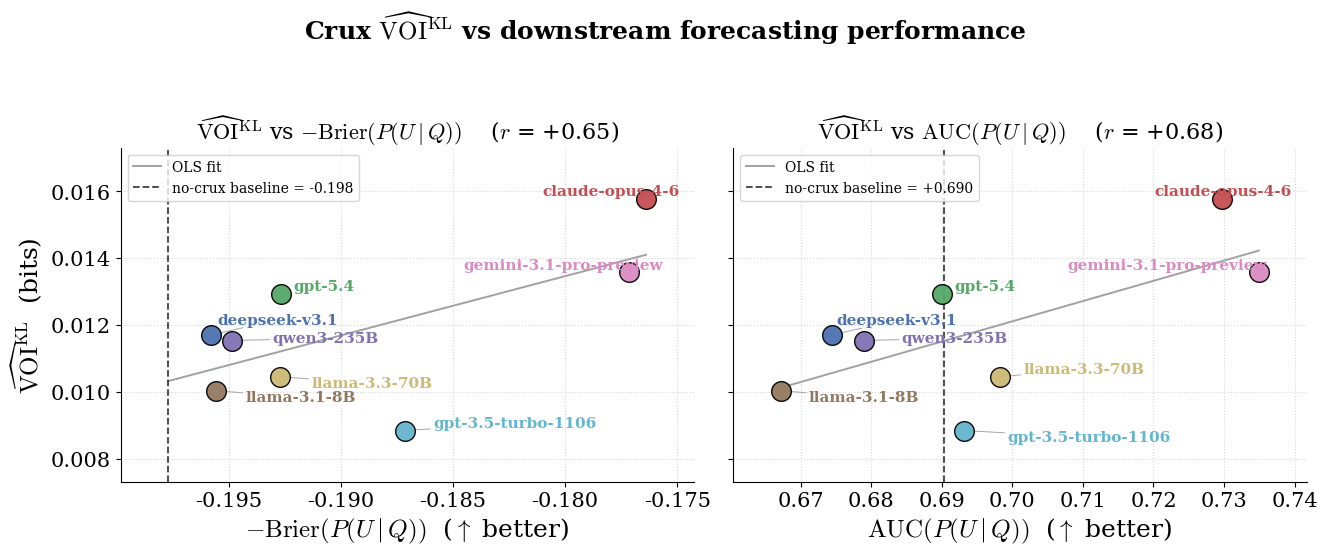

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.4), sharey=True)
_scatter_panel(
    axes[0], downstream_df, x_col='cross Brier', y_col='KL', flip_x=True,
    x_metric_label=r'$-\mathrm{Brier}(P(U \mid Q))$', y_metric_label=VOI_LABEL,
    baseline_x=-cross_brier_baseline,
)
_scatter_panel(
    axes[1], downstream_df, x_col='cross AUC', y_col='KL', flip_x=False,
    x_metric_label=r'$\mathrm{AUC}(P(U \mid Q))$', y_metric_label=VOI_LABEL,
    baseline_x=cross_auc_baseline,
)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.3f}'))
axes[0].set_ylabel(rf'{VOI_LABEL}  (bits)')
for ax in axes:
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    ax.tick_params(axis='both', labelsize=15)
    ax.legend(loc='upper left', frameon=True)
y = downstream_df['KL'].values
y_pad = 0.22 * (y.max() - y.min())
axes[0].set_ylim(y.min() - y_pad, y.max() + y_pad)
fig.suptitle(rf'Crux {VOI_LABEL} vs downstream forecasting performance',
             fontsize=18, fontweight='bold', y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'voi_vs_downstream_forecasting.pdf', bbox_inches='tight')
plt.show()


## Figure 4: Cross-model crux similarity

Cosine similarities use OpenAI `text-embedding-3-small` embeddings of the concatenated crux question and resolution criteria. The release includes the derived pairwise cosine scores rather than the full embedding vectors.

In [12]:
SIM_KEYS = ['opus', 'gemini', 'gpt54', 'deepseek', 'qwen', 'llama70b', 'llama8b', 'gpt35']
SIM_NAMES = {
    'opus': 'Claude-Opus-4.6',
    'gemini': 'Gemini-3.1-Pro-Preview',
    'gpt54': 'GPT-5.4',
    'deepseek': 'DeepSeek-V3.1',
    'qwen': 'Qwen3-235B-A22B',
    'llama70b': 'Llama-3.3-70B',
    'llama8b': 'Llama-3.1-8B-Instruct',
    'gpt35': 'GPT-3.5-Turbo',
}

pair_df = pd.read_json(SIM_PAIRS).rename(columns={
    'same_resolution': 'res_agree',
    'date_gap_days': 'dt_diff_days',
})
assert pair_df['parent'].nunique() == 293

M = len(SIM_KEYS)
mean_matrix = np.full((M, M), np.nan)
for i, left in enumerate(SIM_KEYS):
    for j, right in enumerate(SIM_KEYS):
        if i == j:
            continue
        values = pair_df.loc[
            ((pair_df.a == left) & (pair_df.b == right))
            | ((pair_df.a == right) & (pair_df.b == left)),
            'cosine',
        ]
        mean_matrix[i, j] = values.mean()

per_market = pair_df.groupby('parent').cosine.mean()
offdiag_mean = per_market.mean()
offdiag_ci = 1.96 * per_market.std(ddof=1) / np.sqrt(len(per_market))

BINS = [0.0, 0.6, 0.7, 0.8, 1.0]
LABELS = ['[0, 0.6]', '(0.6, 0.7]', '(0.7, 0.8]', '(0.8, 1.0]']


def wilson_ci(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan
    probability = k / n
    denominator = 1 + z ** 2 / n
    center = (probability + z ** 2 / (2 * n)) / denominator
    half_width = z * np.sqrt(
        probability * (1 - probability) / n + z ** 2 / (4 * n ** 2)
    ) / denominator
    return max(0.0, center - half_width), min(1.0, center + half_width)

resolution_pairs = pair_df.dropna(subset=['res_agree']).copy()
datetime_pairs = pair_df.dropna(subset=['dt_diff_days']).copy()
resolution_pairs['band'] = pd.cut(
    resolution_pairs.cosine, BINS, labels=LABELS, include_lowest=True
)
datetime_pairs['band'] = pd.cut(
    datetime_pairs.cosine, BINS, labels=LABELS, include_lowest=True
)
band = pd.DataFrame({
    'n': resolution_pairs.groupby('band', observed=False).res_agree.size(),
    'k': resolution_pairs.groupby('band', observed=False).res_agree.sum(),
    'median_days': datetime_pairs.groupby('band', observed=False).dt_diff_days.median(),
})
band['p_same'] = band.k / band.n
band[['lo', 'hi']] = [wilson_ci(k, n) for k, n in zip(band.k, band.n)]
print(f'Mean pairwise cosine similarity: {offdiag_mean:.3f} ± {offdiag_ci:.3f} (95% CI)')
band


Mean pairwise cosine similarity: 0.752 ± 0.007 (95% CI)


,n,k,median_days,p_same,lo,hi
band,,,,,,
"[0, 0.6]",558,315.0,7.123258,0.564516,0.523074,0.605076
"(0.6, 0.7]",1394,834.0,5.531238,0.598278,0.572306,0.623710
"(0.7, 0.8]",2463,1650.0,2.265961,0.669915,0.651091,0.688209
"(0.8, 1.0]",2601,1979.0,0.000000,0.760861,0.744091,0.776862


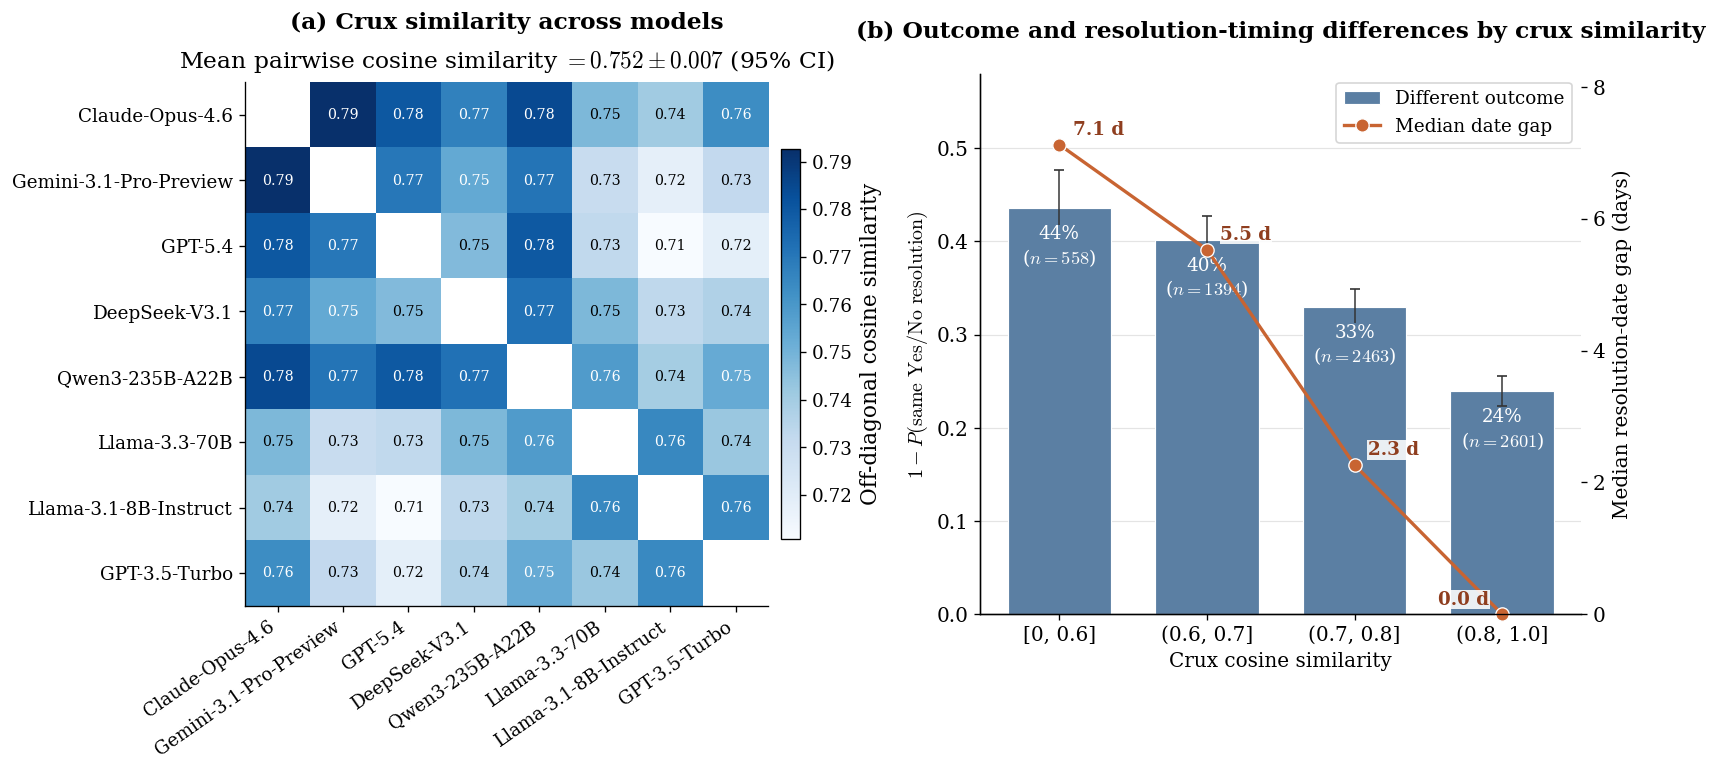

In [13]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13.8, 6.2), dpi=120,
    gridspec_kw={'width_ratios': [1.05, 1]},
)
CMAP, BAR, LINE, LINE_DARK = 'Blues', '#5B7FA3', '#C86432', '#8F3E1F'

# (a) Mean cosine similarity for each model pair; diagonal intentionally blank.
offdiag = mean_matrix[~np.eye(M, dtype=bool)]
vmin, vmax = float(np.nanmin(offdiag)), float(np.nanmax(offdiag))
plot_matrix = np.ma.masked_where(np.eye(M, dtype=bool), mean_matrix)
cmap = plt.get_cmap(CMAP).copy()
cmap.set_bad('white')
image = ax1.imshow(plot_matrix, vmin=vmin, vmax=vmax, cmap=cmap)
labels = [SIM_NAMES[key] for key in SIM_KEYS]
ax1.set_xticks(range(M)); ax1.set_yticks(range(M))
ax1.set_xticklabels(labels, rotation=35, ha='right')
ax1.set_yticklabels(labels)
for i in range(M):
    for j in range(M):
        if i != j:
            ax1.text(
                j, i, f'{mean_matrix[i, j]:.2f}', ha='center', va='center', fontsize=8.5,
                color='white' if mean_matrix[i, j] > (vmin + vmax) / 2 else 'black',
            )
ax1.set_title('(a) Crux similarity across models', fontweight='bold', pad=32)
ax1.text(
    0.5, 1.015,
    f'Mean pairwise cosine similarity $= {offdiag_mean:.3f} \\pm {offdiag_ci:.3f}$ (95% CI)',
    transform=ax1.transAxes, ha='center', va='bottom', fontsize=14,
)
fig.colorbar(image, ax=ax1, shrink=0.72, pad=0.02, label='Off-diagonal cosine similarity')

# (b) Outcome disagreement and median resolution-date gap by similarity band.
x = np.arange(len(band))
p_diff = 1 - band.p_same
diff_lo, diff_hi = 1 - band.hi, 1 - band.lo
ax2.bar(x, p_diff, color=BAR, edgecolor='white', linewidth=0.7, width=0.7,
        label='Different outcome', zorder=2)
ax2.errorbar(x, p_diff, yerr=[p_diff - diff_lo, diff_hi - p_diff],
             fmt='none', ecolor='#333', capsize=3, lw=0.9, zorder=3)
for xi, (probability, n) in enumerate(zip(p_diff, band.n)):
    ax2.text(xi, probability - 0.018, f'{probability:.0%}\n($n={n}$)',
             ha='center', va='top', fontsize=11, color='white',
             bbox=dict(facecolor=BAR, edgecolor='none', pad=0.5))
ax2.set_xticks(x); ax2.set_xticklabels(band.index)
ax2.set_xlabel('Crux cosine similarity', fontsize=12)
ax2.set_ylabel(r'$1-P(\mathrm{same\ Yes/No\ resolution})$', fontsize=12)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_ylim(0, 0.58)
ax2.grid(axis='y', color='#D9D9D9', linewidth=0.7, alpha=0.7, zorder=0)
ax2.set_title('(b) Outcome and resolution-timing differences by crux similarity\n',
              fontweight='bold')

ax3 = ax2.twinx()
ax3.plot(x, band.median_days, '-o', color=LINE, lw=2, ms=8,
         mec='white', mew=0.8, clip_on=False, label='Median date gap')
for xi, days in enumerate(band.median_days):
    last = xi == len(band) - 1
    ax3.annotate(
        f'{days:.1f} d', (xi, days), xytext=((-8 if last else 8), 6),
        textcoords='offset points', ha=('right' if last else 'left'),
        color=LINE_DARK, fontsize=11, fontweight='semibold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.88, pad=0.4),
    )
ax3.set_ylabel('Median resolution-date gap (days)', fontsize=12)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_ylim(0, 8.2); ax3.set_yticks([0, 2, 4, 6, 8])
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper right', fontsize=11)

fig.tight_layout()
fig.savefig(FIG_DIR / 'cross_model_similarity.pdf', bbox_inches='tight')
plt.show()
